# Lab 2: Data Science Basics

***
- **FIRST name**: Moffat
- **LAST name**: Muriithi
- **Student ID**: 1864875

Leave blank if individual:
- **Collaborator names**:
- **Collaborator student IDs**:
***

In today's lab, you will learn how to:

1.   visualize data;
2.   use NumPy and Pandas to simulate randomness and probabilities.

For this lab, you will need two datasets: <code>canada_population.csv</code>, and <code>exam_scores.csv</code>.

### Instructions

- **Collaboration**: You must submit your own work. The collaboration policy for the labs is Consultation Collaboration. You may verbally discuss concepts with your classmates, without exchanging written text, code, or detailed advice. You must develop your own solution and submit your own work. All sources of information used including books, websites, students you talked to, must be cited in the submission. Please see the course FAQ document for details on this collaboration policy. We will adhere to current Faculty of Science guidelines on dealing with suspected cases of plagiarism.
- **Software**: We highly recommend that students use Syzygy for completing labs and assignments. This is the software used by the TAs in the course, and we can guarantee that there will be no issues with incompatible environments or imports.
- **Filling out the Notebook**: You must use this notebook to complete your lab. You will execute the questions in the notebook. The questions might ask for a short answer in text form or for you to write and execute a piece of code. Make sure you enter your answer in either case only in the cell provided.
- **Important**:  Do not use a different cell, do not delete cells, and do not create a new cell. Creating new cells for your code is not compatible with the auto-grading system we are using and thus your assignment will not get grading properly and you will lose marks for that question. As a reminder you must remove the raise NotImplementedError() statements from each question when answering.
- **Rules for Datasets**: Any datasets used in the lab cannot be imported from cloud storage, e.g google drive, and must be read from a file either on your local computer or uploaded to the google colab notebook. Importing from cloud storage will result in a zero.
- **Submission Formatting**: When you are done, you will submit your work from the notebook. Make sure to save your notebook before running it, and then submit on Canvas the notebook file with your work completed. Name your file with an L followed by the lab number (ex: L2.ipynb). Failure to do so will result in a zero! Finally your name must be written at the top of the lab or assignment document.

# 1. Plotting

To visualize our data in Python, we will import a new library called <code>matplotlib</code>. Run the following cell without changing it:

In [1]:
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)


<p> Import the dataset titled <code>canada_population.csv</code>. This dataset contains the population of Canada from 2010 to 2024. </p>

It may be useful to plot this data to better understand the underlying trends. The code below displays the data using a *line graph*.

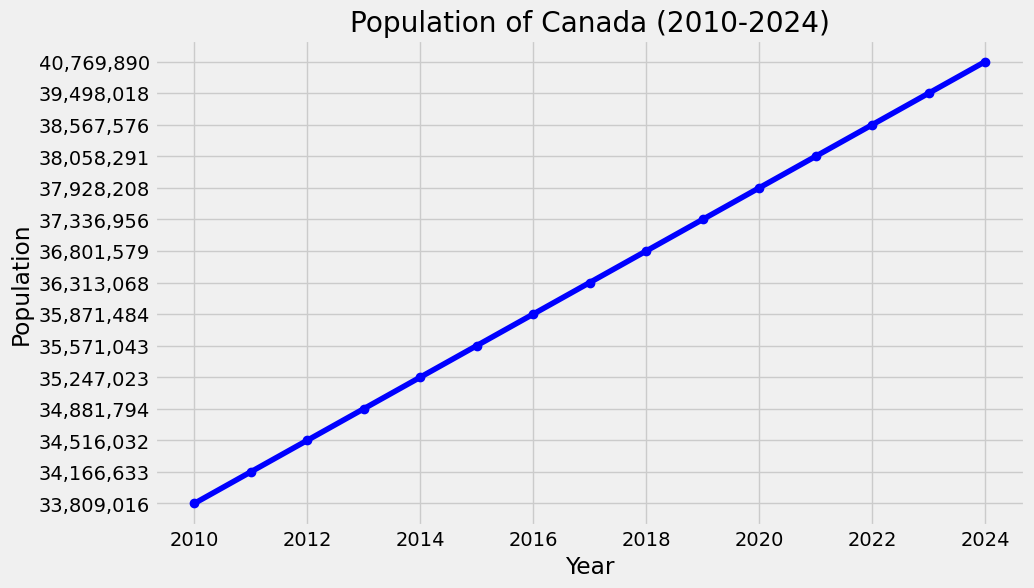

In [2]:
# create a DataFrame named population_data
population_data = pd.read_csv("canada_population.csv")

# plotting the data...
plt.figure(figsize = (10, 6))
plt.plot(population_data['Year'], population_data['Population'], marker = 'o', linestyle = '-', color = 'blue')
plt.title('Population of Canada (2010-2024)')
plt.xlabel('Year')
plt.ylabel('Population')
plt.grid(True)
plt.show()


**Question 1.1.** Use the same data above to plot the population of Canada between 2013 and 2020 (inclusive). Make sure you include a proper title and labels.

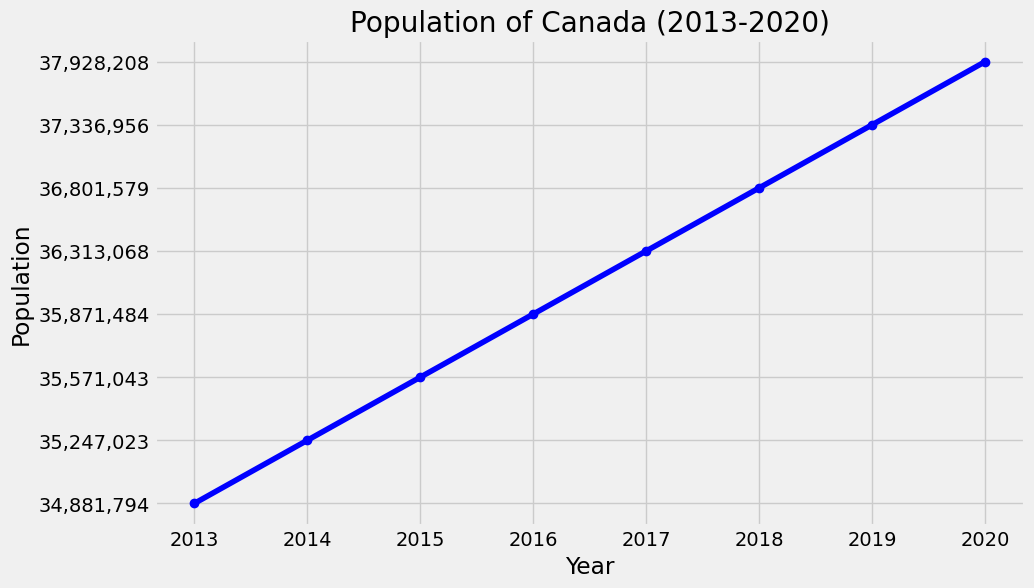

In [7]:
# YOUR CODE HERE
#configure dataframe to only have between the years 2013 and 2020
population_data1 = population_data[population_data['Year'] >= 2013]
population_data2 = population_data1[population_data1['Year'] <= 2020]
# plotting the data...
plt.figure(figsize = (10, 6))
plt.plot(population_data2['Year'], population_data2['Population'], marker = 'o', linestyle = '-', color = 'blue')
plt.title('Population of Canada (2013-2020)')
plt.xlabel('Year')
plt.ylabel('Population')
plt.grid(True)

plt.show()

## Histograms

Another useful type of graph is called the *histogram*. A histogram is used for showing the distribution of numeric data using bars. The height of a bar indicates the frequency and its width tells us what bin or class it's in. </p>

The dataset <code>exam_scores.csv</code> contains fictional math scores across two categories: females and males. Upload the dataset and run the cells below.



In [8]:
exam_scores = pd.read_csv('exam_scores.csv')

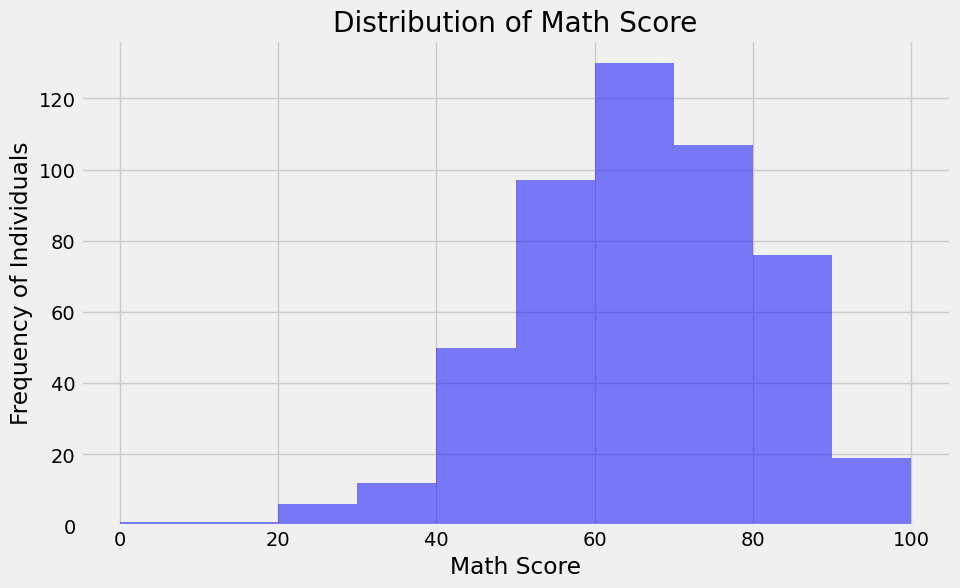

In [9]:
math_scores = exam_scores['MathScore']  # the data we are plotting

plt.figure(figsize = (10, 6))  # controls the size
plt.hist(math_scores, bins = 10, alpha = 0.5, color = 'blue')  # alpha controls the transparency of the bars

# plot the titles
plt.xlabel('Math Score')
plt.ylabel('Frequency of Individuals')
plt.title('Distribution of Math Score')

plt.show()

This histogram is slightly left-skewed with a mode at around 65. We can see that the score with the lowest frequency of individuals is 0-20, while the highest is 60-70.

**Question 1.2.** Plot a histogram that shows the distribution of female and male scores separately. You can choose how you want to represent the histograms: two separate sub plots side by side, or both on one plot with different colours each, etc.  The axis limits should be same on both plots (same scale) and the plots should have appropriate titles, axis labels, and if needed a legend.

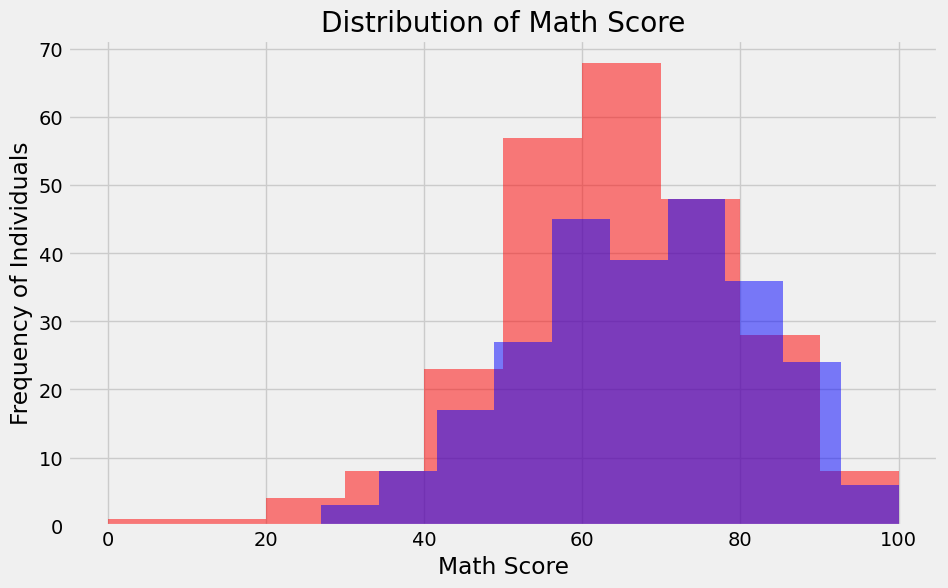

In [18]:
# YOUR CODE HERE
#df = pd.DataFrame(exam_scores)
#df.head(5)
exam_scoresFemale = exam_scores[exam_scores['Gender'] == 'female']
exam_scoresMale = exam_scores[exam_scores['Gender'] == 'male']

math_scores = exam_scoresFemale['MathScore']  # the data we are plotting
math_scores2 = exam_scoresMale['MathScore']

plt.figure(figsize = (10, 6))  # controls the size
plt.hist(math_scores, bins = 10, alpha = 0.5, color = 'red')  # alpha controls the transparency of the bars
plt.hist(math_scores2, bins = 10, alpha = 0.5, color = 'blue')  # alpha controls the transparency of the bars

# plot the titles
plt.xlabel('Math Score')
plt.ylabel('Frequency of Individuals')
plt.title('Distribution of Math Score')
#plt.legend()
plt.show()

**Question 1.3.** Describe the overall shape of your histogram and what it means. What differences do you see between genders? What are their similarities?

The histogram for the females(red) is slightly left skewed.
The histogram for the males(blue) is left skewed.
This means that the median scores of both datasets is greater than the mean
Differences:
  Histogram for the females has the score with the lowest frequency of individuals between 0 - 20 while the 
  histogram for the males has score with the lowest frequency of individuals between around 28 - 32.

  Histogram for the females has the score with the highest frequency of individuals between 60 - 70 while the 
  histogram for the males has score with the highest frequency of individuals between around 72 - 78.

  Mode for the histogram for the females is around a score of 65 while mode for the histogram for the males     is around a score of 75

Similarities: They have an equal amount of frequency of individuals between the scores of 72 - 78 and 32 - 40

# 2. Randomness and Probabilities

Suppose you have a bag of poker chips where one is blue, one is red, one is black, and one is green. We can use NumPy to simulate picking a chip out of the bag at random by using the function <code>np.random.choice(...)</code>. Run the code below multiple times to see the different choices that the function prints.

In [20]:
# bag is an array that holds our different colored chips
bag = ['blue', 'red', 'black', 'green']
np.random.choice(bag)


np.str_('black')

Adding a second argument to the function will give us a new array with a number of random choices.

In [21]:
np.random.choice(bag, 10)

array(['black', 'black', 'blue', 'blue', 'blue', 'red', 'green', 'blue',
       'blue', 'blue'], dtype='<U5')

The function <code>np.count_nonzero</code> counts the number of non-zero values that appear in an array. In Python, the boolean value <code>True</code> is coded as 1 and the boolean value <code>False</code> is coded as 0. </p>

Run the next cell to see how <code>np.count_nonzero</code> works.

In [22]:
an_array = [True, False, False, True, False, True, True]
np.count_nonzero(an_array)

np.int64(4)

**Question 2.1.** Suppose that we have a bigger bag of poker chips that have multiples of each color. We use <code>np.array</code> so that we can use comparison operators on every element in the array. Find the number of red chips in the bigger bag using a comparison operator (e.g.<code>==</code>, <code><</code>, ...) and the <code>np.count_nonzero</code> function. Assign your answer to <code>number_red</code>. Do NOT hardcode the answer!

In [41]:
bigger_bag = np.array(['red', 'black', 'red', 'green', 'blue', 'blue', 'black', 'red',
       'red', 'black', 'red', 'red', 'red', 'blue', 'green'])

# YOUR CODE HERE
def color_count(array, color):
    count = np.count_nonzero(array == color)
    return count
number_red = color_count(bigger_bag, 'red')
number_red

np.int64(7)

In [ ]:
# CELL USED FOR AUTOGRADER: do not delete!

## Distributions

We can use our poker chip example to learn more about distrbutuions. Distributions tell us the 'behaviour' of a variable and the probability of an event happening under a certain distribution. We will focus on three different types:

1. **Uniform distribution**: When a variable has a uniform distibution, it means that every event has an equal probability of happening. Visually, the graph of this variable is flat across all categories.
2. **Normal / Gaussian distribution**: Normal distributions often have a bell shape where most of the values are concentrated at the center (mean), with fewer values at the extremes. The graph of this distribution is symmetric, meaning it isn’t skewed in any direction. A normal distribution can have any mean (μ) and variance (σ²). A special case is the standard normal distribution, which has mean μ = 0 and variance σ² = 1. Other normal distributions can be transformed into this standard version using a process called standardization.
3. **Binomial / Bernoulli distribution**: The distribution of a variable is Bernoulli when the outcomes are *binary* (only two possible outcomes). Examples include flipping a coin where the only outcomes are heads or tails, or taking a class that's pass or fail. The graph of this distribution only has two bars representing the two outcomes.

Run the code below to visualize the different distributions:

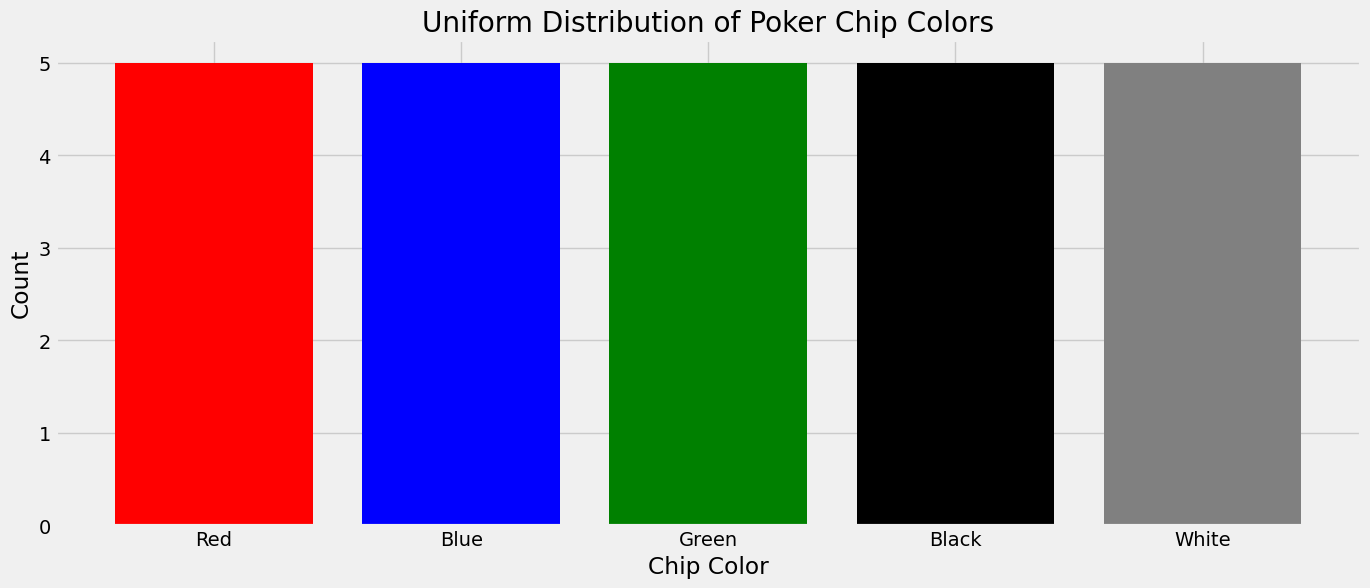

In [33]:
chip_colors = ['Red', 'Blue', 'Green', 'Black', 'White']
chip_counts = [5, 5, 5, 5, 5]

plt.figure(figsize=(15, 6))
plt.bar(chip_colors, chip_counts, color=['red', 'blue', 'green', 'black', 'grey'])
plt.xlabel('Chip Color')
plt.ylabel('Count')
plt.title('Uniform Distribution of Poker Chip Colors')
plt.show()

Since each color of chip has the same count, the distribution is uniform. </p>

When the distribution is uniform, the probability of choosing any color is the the same across all categories. To calculate the probability, divide the count of the color by the total count. We can write: </p>

P(Red) = P(Blue) = P(Green) = P(Black) = P(White) = $\frac{5}{25}$ = 0.2.

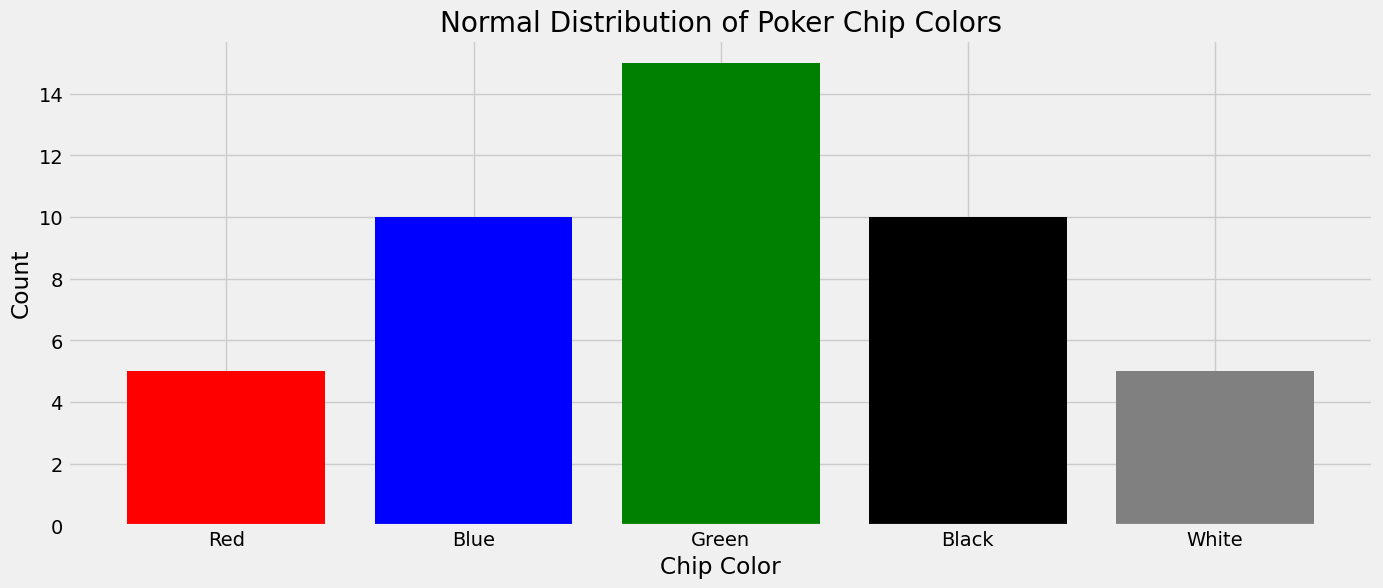

In [34]:
chip_colors = ['Red', 'Blue', 'Green', 'Black', 'White']
chip_counts = [5, 10, 15, 10, 5]

plt.figure(figsize=(15, 6))
plt.bar(chip_colors, chip_counts, color=['red', 'blue', 'green', 'black', 'grey'])
plt.xlabel('Chip Color')
plt.ylabel('Count')
plt.title('Normal Distribution of Poker Chip Colors')
plt.show()

Assume that the chips are ordered based on value. Since the graph is symmetrical around the center, the distribution is Normal. </p>

Calculating the probabilities follows the same steps for uniform, however, the probabilities won't be the same for every color.

**Question 2.2.** What is the probability of choosing a green chip out of the bag with the normal distribution? What is the probability of choosing a black chip **or** a blue chip out of the bag with the normal distribution? Assign your answers to <code>prob_green</code> and <code>prob_black_or_blue</code> repectively. Do not round your answer.

In [48]:
# YOUR CODE HERE
prob_green = 15/45
prob_black_or_blue = (10/45) + (10/45) - (10/45)**2

print(prob_green)
print(prob_black_or_blue)

0.3333333333333333
0.3950617283950617


In [ ]:
# CELL USED FOR AUTOGRADER: do not delete!

Since Binomial only has two outcomes, we will simulate only having two colors of chips in the bag:

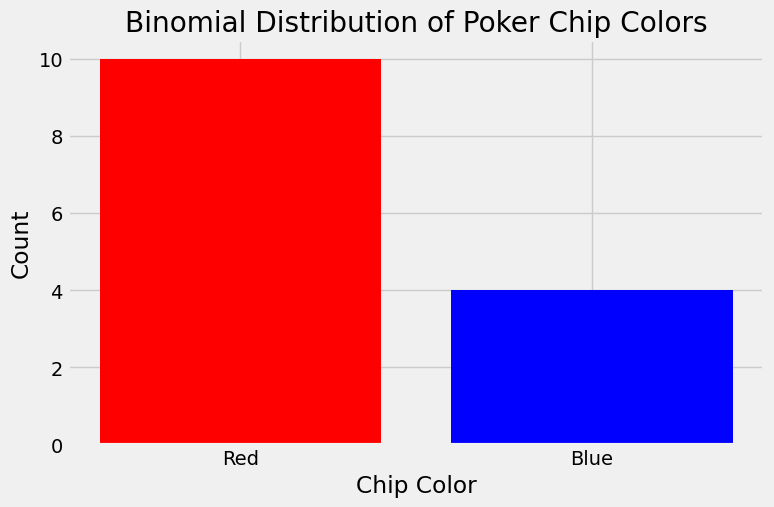

In [36]:
chip_colors = ['Red', 'Blue']
chip_counts = [10, 4]

plt.figure(figsize=(8, 5))
plt.bar(chip_colors, chip_counts, color=['red', 'blue'])
plt.xlabel('Chip Color')
plt.ylabel('Count')
plt.title('Binomial Distribution of Poker Chip Colors')
plt.show()

A key characteristic of probabilities is that the sum of each individual probability is always one. Therefore, for Bernoulli distributions, if we know the probability of one event happening, we can simply subtract that value from one to find the other probability. Written mathematically, </p>

P(success) = p </p>
P(failure) = 1 - p

**Question 2.3.** Let a random variable, X, follow a Bernoulli distribution. If we know that P(failure) = 0.65, what is P(success)? Assign your answer to <code>prob_success</code>.

In [37]:
# YOUR CODE HERE
prob_success = 1 - 0.65

prob_success

0.35

In [ ]:
# CELL USED FOR AUTOGRADER: do not delete!

## Conditional Statements

A conditional statement is a multi-line statement that depends on if something is True or False. Python uses an <code>if</code>, <code>elif</code>, <code>else</code> structure. </p>

Below is a simple example that uses <code>type</code> to see if the argument is an integer.

In [38]:
def is_integer(x):
  if type(x) == int:
    print(x, "is an integer.")
  else:
    print(x, "is not an integer.")

is_integer(4)
is_integer('Hello')

4 is an integer.
Hello is not an integer.


When x is an integer, Python executes the code after the <code>if</code> statement. If x is not an integer, Python continues to the <code>else</code> statement and executes the code that follows it. </p>

We can have nested if-else statements. The statement that follows the first <code>if</code> statement is called an <code>elif</code> statement.

In [39]:
def is_integer(x):
  if type(x) == int:
    print(x, "is an integer.")
  elif type(x) == str:
    print(x, "is a string.")
  elif type(x) == float:
     print(x, "is a float.")
  else:
     print(x, "is not an integer, string, or float.")

is_integer(4)
is_integer('Hello')
is_integer(56.7)
is_integer(True)

4 is an integer.
Hello is a string.
56.7 is a float.
True is not an integer, string, or float.


Nested conditional statements are executed top-down (in the order that they appear). If every if and elif statement is executed and none of them hold, the else statement is executed.

**Question 2.4.** Complete the conditional statement below that prints <code>"There are 7 or more red chips!"</code> if there are 7 or more red chips in the bigger bag (use your definition of <code>number_red</code> from question 2.1., you do NOT have to redefine it).

In [42]:
statement = '?'

#Complete the if statement below
# YOUR CODE HERE
if number_red >= 7:
  statement = "There are 7 or more red chips!"  #this is the body of the if statement
statement

'There are 7 or more red chips!'

In [ ]:
# CELL USED FOR AUTOGRADER: do not delete!

**Question 2.5.** In poker, each chip is worth a different value. Say that a red chip is worth 5 points, blue is worth 10 points, green is worth 25 points, and black is worth 100 points. Write a function that takes in a color (as a string) and returns how many points that color is worth.

In [43]:
def chip_value(color):
    if color == 'red':
        return('Red is worth 5 points.')
    # write conditional statements for the other colors
# YOUR CODE HERE
    if color == 'blue':
        return('Blue is worth 10 points.')
    if color == 'green':
        return('Green is worth 25 points.')
    if color == 'black':
        return('Black is worth 100 points.')

# example call
blue = chip_value('blue')
blue

'Blue is worth 10 points.'

In [ ]:
# CELL USED FOR AUTOGRADER: do not delete!
### TESTS
assert(chip_value('blue') == 'Blue is worth 10 points.')
assert(chip_value('red') == 'Red is worth 5 points.')


## Simulations and Probabilities

We can also use probabilities to ask questions about the data in our tables. </p>

Suppose we have a survey where participants rate their satisfaction with a product as "High", "Medium", or "Low". The participants are put into age groups labelled "Young", "Middle-aged", or "Elderly". Run the cell below to load the data.


In [44]:
satisfaction = np.random.choice(['High', 'Medium', 'Low'], 115)
age_group = np.random.choice(['Young', 'Middle-aged', 'Elderly'], 115)

survey_data = pd.DataFrame({
    'Satisfaction Level': satisfaction,
    'Age Group': age_group
})

survey_data

,Satisfaction Level,Age Group
0,Low,Elderly
1,Medium,Middle-aged
2,Low,Elderly
3,Low,Middle-aged
4,Low,Elderly
...,...,...
110,Low,Middle-aged
111,Medium,Middle-aged
112,High,Young
113,High,Elderly


**Question 2.6.** Calculate the probability that a participant is Middle-aged and rated the product as Medium. Assign the probability to <code>middle_aged_medium_probability</code>.

In [51]:
# YOUR CODE HERE
survey_data2 = survey_data[survey_data['Age Group'] == 'Middle-aged']
survey_data3 = survey_data[survey_data['Satisfaction Level'] == 'Medium']

len_middle_aged = len(survey_data2)
len_sat_med = len(survey_data3)

middle_aged_medium_probability = ((len_middle_aged)/115) * ((len_sat_med)/115)


print("Probability of being Middle-aged and having Medium satisfaction level:", middle_aged_medium_probability)

Probability of being Middle-aged and having Medium satisfaction level: 0.07984877126654064


In [ ]:
# CELL USED FOR AUTOGRADER: do not delete!

# Rubric

| Question | Points|
|----------|----------|
| 1.1.   | 15   |
| 1.2.    | 15  |
| 1.3.   | 5   |
| 2.1.    | 5   |
| 2.2.    | 6   |
| 2.3.   | 5   |
| 2.4.    | 3  |
| 2.5.   | 6   |
| 2.6.   | 9  |
| Total:    | 69   |
